# Dog Project

-DSC-4900-01: Data Science Project/Portfolio (Spring 2026)

-Jayden Cruz

- https://medium.com/@soyoungluna/simple-explanation-of-lightgbm-without-complicated-mathematics-973998ec848f
-


In [13]:
#basic imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from jinja2.filters import do_groupby
from sklearn.metrics import dcg_score

#imports for model(LightGBM)
#from sklearn.model_selection import train_test_split
#from lightgbm import LGBMClassifier, LGBMRegressor
#import lightgbm as lgb


#import for metrics
#from sklearn.metrics import accuracy_score


In [1]:
import pandas as pd
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

# Download VADER lexicon (only needed once)
nltk.download('vader_lexicon')

# Load data
test = pd.read_csv('/Users/jaydencruz/PycharmProjects/DogProject/data/test.csv')
train = pd.read_csv('/Users/jaydencruz/PycharmProjects/DogProject/data/train.csv')

# Initialize analyzer
sia = SentimentIntensityAnalyzer()

def add_sentiment_scores(df):
    # Handle missing descriptions gracefully
    descriptions = df['Description'].fillna('')

    # Apply VADER to each description
    scores = descriptions.apply(lambda text: sia.polarity_scores(text))

    # Expand the scores dict into separate columns
    df['sentiment_neg']      = scores.apply(lambda s: s['neg'])
    df['sentiment_neu']      = scores.apply(lambda s: s['neu'])
    df['sentiment_pos']      = scores.apply(lambda s: s['pos'])
    df['sentiment_compound'] = scores.apply(lambda s: s['compound'])

    return df

# Apply to both datasets
train = add_sentiment_scores(train)
test  = add_sentiment_scores(test)

# Preview results
print(train[['Description', 'sentiment_neg', 'sentiment_neu', 'sentiment_pos', 'sentiment_compound']].head())
print(test[['Description', 'sentiment_neg', 'sentiment_neu', 'sentiment_pos', 'sentiment_compound']].head())

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/jaydencruz/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


                                         Description  sentiment_neg  \
0  Nibble is a 3+ month old ball of cuteness. He ...          0.000   
1  I just found it alone yesterday near my apartm...          0.149   
2  Their pregnant mother was dumped by her irresp...          0.095   
3  Good guard dog, very alert, active, obedience ...          0.000   
4  This handsome yet cute boy is up for adoption....          0.000   

   sentiment_neu  sentiment_pos  sentiment_compound  
0          0.745          0.255              0.9552  
1          0.723          0.129              0.1280  
2          0.706          0.200              0.7650  
3          0.483          0.517              0.9538  
4          0.635          0.365              0.9880  
                                         Description  sentiment_neg  \
0  Dopey Age: 8mths old Male One half of a pair, ...          0.000   
1  Please note that Chichi has been neutered, the...          0.043   
2  Sticky, named such because of his

<Axes: >

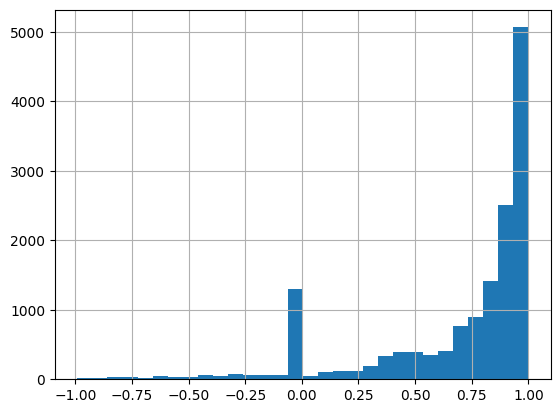

In [2]:
train['sentiment_compound'].describe()
train['sentiment_compound'].hist(bins=30)

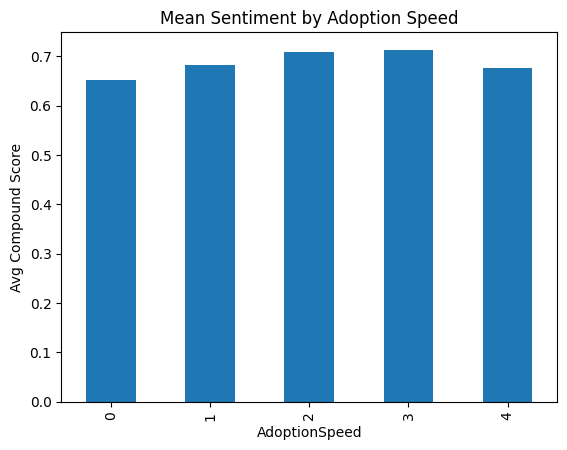

In [3]:
import matplotlib.pyplot as plt

# See if sentiment correlates with your target variable
train.groupby('AdoptionSpeed')['sentiment_compound'].mean().plot(kind='bar')
plt.title('Mean Sentiment by Adoption Speed')
plt.ylabel('Avg Compound Score')
plt.show()

In [5]:
# Description length — more effort = more adoptable?
train['desc_length'] = train['Description'].fillna('').apply(len)

# Word count
train['desc_word_count'] = train['Description'].fillna('').apply(lambda x: len(x.split()))

# Is description empty?
train['has_description'] = train['Description'].fillna('').apply(lambda x: int(len(x) > 0))

In [1]:
#read in data
test = pd.read_csv('/Users/jaydencruz/PycharmProjects/DogProject/data/test.csv')
train = pd.read_csv('/Users/jaydencruz/PycharmProjects/DogProject/data/train.csv')
BreedLabels = pd.read_csv('/Users/jaydencruz/PycharmProjects/DogProject/data/BreedLabels.csv')
ColorLabels = pd.read_csv('/Users/jaydencruz/PycharmProjects/DogProject/data/ColorLabels.csv')
StateLabels = pd.read_csv('/Users/jaydencruz/PycharmProjects/DogProject/data/StateLabels.csv')

NameError: name 'pd' is not defined

In [19]:
# includes photo info will most likely will not use photos
print("test\n", test.head())
print("train\n",train.head())
print("breedlabels\n", BreedLabels.head())
print("colorlabels\n",ColorLabels.head())
print("statelabels\n",StateLabels.head())

test
    Type                       Name  Age  Breed1  Breed2  Gender  Color1  \
0     2               Dopey & Grey    8     266     266       1       2   
1     2                    Chi Chi   36     285     264       2       1   
2     2                     Sticky    2     265       0       1       6   
3     1  Dannie & Kass [In Penang]   12     307       0       2       2   
4     2                    Cuddles   12     265       0       1       2   

   Color2  Color3  MaturitySize  ...  Sterilized  Health  Quantity  Fee  \
0       6       7             1  ...           2       1         2    0   
1       4       7             2  ...           1       2         1    0   
2       7       0             2  ...           2       1         1  200   
3       5       0             2  ...           1       1         2    0   
4       3       7             2  ...           1       1         1    0   

   State                         RescuerID  VideoAmt  \
0  41326  2ece3b2573dcdcebd774e635dc

In [2]:
## NLP (pip install nltk)
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

# Download the VADER lexicon (required the first time)
# nltk.download('vader_lexicon')

# Initialize the sentiment analyzer
sia = SentimentIntensityAnalyzer()

# Define text for analysis
text = "Nibble is a 3+ month old ball of cuteness. He is energetic and playful."
text2 = "I hate belmont"

d = "Brock"
d2 = "Cookie"

dog = "Should I adopt Brock"
dog2 = "Should I adopt Cookie"

# Get sentiment scores
scores = sia.polarity_scores(text)
scores2 = sia.polarity_scores(text2)
ds = sia.polarity_scores(d)
ds2 = sia.polarity_scores(d2)
dscore = sia.polarity_scores(dog)
dscore2 = sia.polarity_scores(dog2)



print(text, scores)
print(text2, scores2)

print(d, ds)
print(d2, ds2)

print(dog, dscore)
print(dog2, dscore2)

## Conclusion does not work for names.

Nibble is a 3+ month old ball of cuteness. He is energetic and playful. {'neg': 0.0, 'neu': 0.524, 'pos': 0.476, 'compound': 0.8442}
I hate belmont {'neg': 0.787, 'neu': 0.213, 'pos': 0.0, 'compound': -0.5719}
Brock {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
Cookie {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
Should I adopt Brock {'neg': 0.0, 'neu': 0.541, 'pos': 0.459, 'compound': 0.1779}
Should I adopt Cookie {'neg': 0.0, 'neu': 0.541, 'pos': 0.459, 'compound': 0.1779}
